# PRU Audio Sampler Analysis

This notebook analyzes audio samples captured from the PRU1 audio sampler to evaluate the quality of the frequency band detection and determine if tuning is needed for LED management.

## Datasets
- **baseline.csv**: No music playing (background noise)
- **bagpipes.csv**: Bagpipes song
- **crazy_frog.csv**: Crazy Frog song
- **christmas.csv**: Christmas song

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 10

## 1. Load Data

In [14]:
# Load all datasets
baseline_df = pd.read_csv('baseline.csv')
bagpipes_df = pd.read_csv('bagpipes.csv')
crazy_frog_df = pd.read_csv('crazy_frog.csv')
christmas_df = pd.read_csv('christmas.csv')

# Add dataset identifier
baseline_df['Dataset'] = 'Baseline'
bagpipes_df['Dataset'] = 'Bagpipes'
crazy_frog_df['Dataset'] = 'Crazy Frog'
christmas_df['Dataset'] = 'Christmas'

print(f"Baseline samples: {len(baseline_df)}")
print(f"Bagpipes samples: {len(bagpipes_df)}")
print(f"Crazy Frog samples: {len(crazy_frog_df)}")
print(f"Christmas samples: {len(christmas_df)}")

# Display first few rows
print("\nBaseline data preview:")
baseline_df.head()

Baseline samples: 4775
Bagpipes samples: 4799
Crazy Frog samples: 4799
Christmas samples: 4799

Baseline data preview:


,Sample,Timestamp (s),FFT Count,FFT Rate (Hz),FFT Time (ms),Bass Sum,Mid-Low Sum,Mid-High Sum,Treble Sum,Bass Avg,Mid-Low Avg,Mid-High Avg,Treble Avg,Dataset
0,0,0.030065,388,28.66,2.378,9572627,120651939,72858405,687306593,3190875,5484179,2802246,1494144,Baseline
1,1,0.054179,389,40.45,2.379,8891654,36532246,50170142,343885881,2963884,1660556,1929620,747578,Baseline
2,2,0.079388,390,39.67,2.381,37649862,80858861,116281856,1015976527,12549954,3675402,4472379,2208644,Baseline
3,3,0.104337,391,40.09,2.381,16346638,32728689,35684562,329014480,5448879,1487667,1372483,715248,Baseline
4,4,0.129860,391,0.00,2.381,16346638,32728689,35684562,329014480,5448879,1487667,1372483,715248,Baseline


## 2. Data Quality Assessment

In [15]:
def analyze_data_quality(df, name):
    print(f"\n{'='*60}")
    print(f"Data Quality Report: {name}")
    print(f"{'='*60}")
    
    # Basic statistics
    print(f"\nTotal samples: {len(df)}")
    print(f"Duration: {df['Timestamp (s)'].max():.2f} seconds")
    print(f"\nFFT Performance:")
    print(f"  Average FFT Rate: {df['FFT Rate (Hz)'].mean():.2f} Hz")
    print(f"  Average FFT Time: {df['FFT Time (ms)'].mean():.3f} ms")
    print(f"  Total FFTs: {df['FFT Count'].max()}")
    
    # Check for missing or zero values
    print(f"\nData Integrity:")
    print(f"  Missing values: {df.isnull().sum().sum()}")
    
    # Frequency band statistics
    print(f"\nFrequency Band Statistics (Average):")
    print(f"  Bass Avg: {df['Bass Avg'].mean():.0f}")
    print(f"  Mid-Low Avg: {df['Mid-Low Avg'].mean():.0f}")
    print(f"  Mid-High Avg: {df['Mid-High Avg'].mean():.0f}")
    print(f"  Treble Avg: {df['Treble Avg'].mean():.0f}")

# Analyze all datasets
analyze_data_quality(baseline_df, 'Baseline')
analyze_data_quality(bagpipes_df, 'Bagpipes')
analyze_data_quality(crazy_frog_df, 'Crazy Frog')
analyze_data_quality(christmas_df, 'Christmas')


Data Quality Report: Baseline

Total samples: 4775
Duration: 119.98 seconds

FFT Performance:
  Average FFT Rate: 35.60 Hz
  Average FFT Time: 2.380 ms
  Total FFTs: 4660

Data Integrity:
  Missing values: 0

Frequency Band Statistics (Average):
  Bass Avg: 3035672
  Mid-Low Avg: 2078809
  Mid-High Avg: 1542699
  Treble Avg: 988894

Data Quality Report: Bagpipes

Total samples: 4799
Duration: 119.98 seconds

FFT Performance:
  Average FFT Rate: 35.62 Hz
  Average FFT Time: 2.378 ms
  Total FFTs: 48118

Data Integrity:
  Missing values: 0

Frequency Band Statistics (Average):
  Bass Avg: 16983647
  Mid-Low Avg: 6505648
  Mid-High Avg: 2967662
  Treble Avg: 1099257

Data Quality Report: Crazy Frog

Total samples: 4799
Duration: 119.98 seconds

FFT Performance:
  Average FFT Rate: 35.61 Hz
  Average FFT Time: 2.379 ms
  Total FFTs: 41878

Data Integrity:
  Missing values: 0

Frequency Band Statistics (Average):
  Bass Avg: 43652182
  Mid-Low Avg: 17542870
  Mid-High Avg: 7905073
  Treble

## 3. Frequency Band Distribution Analysis

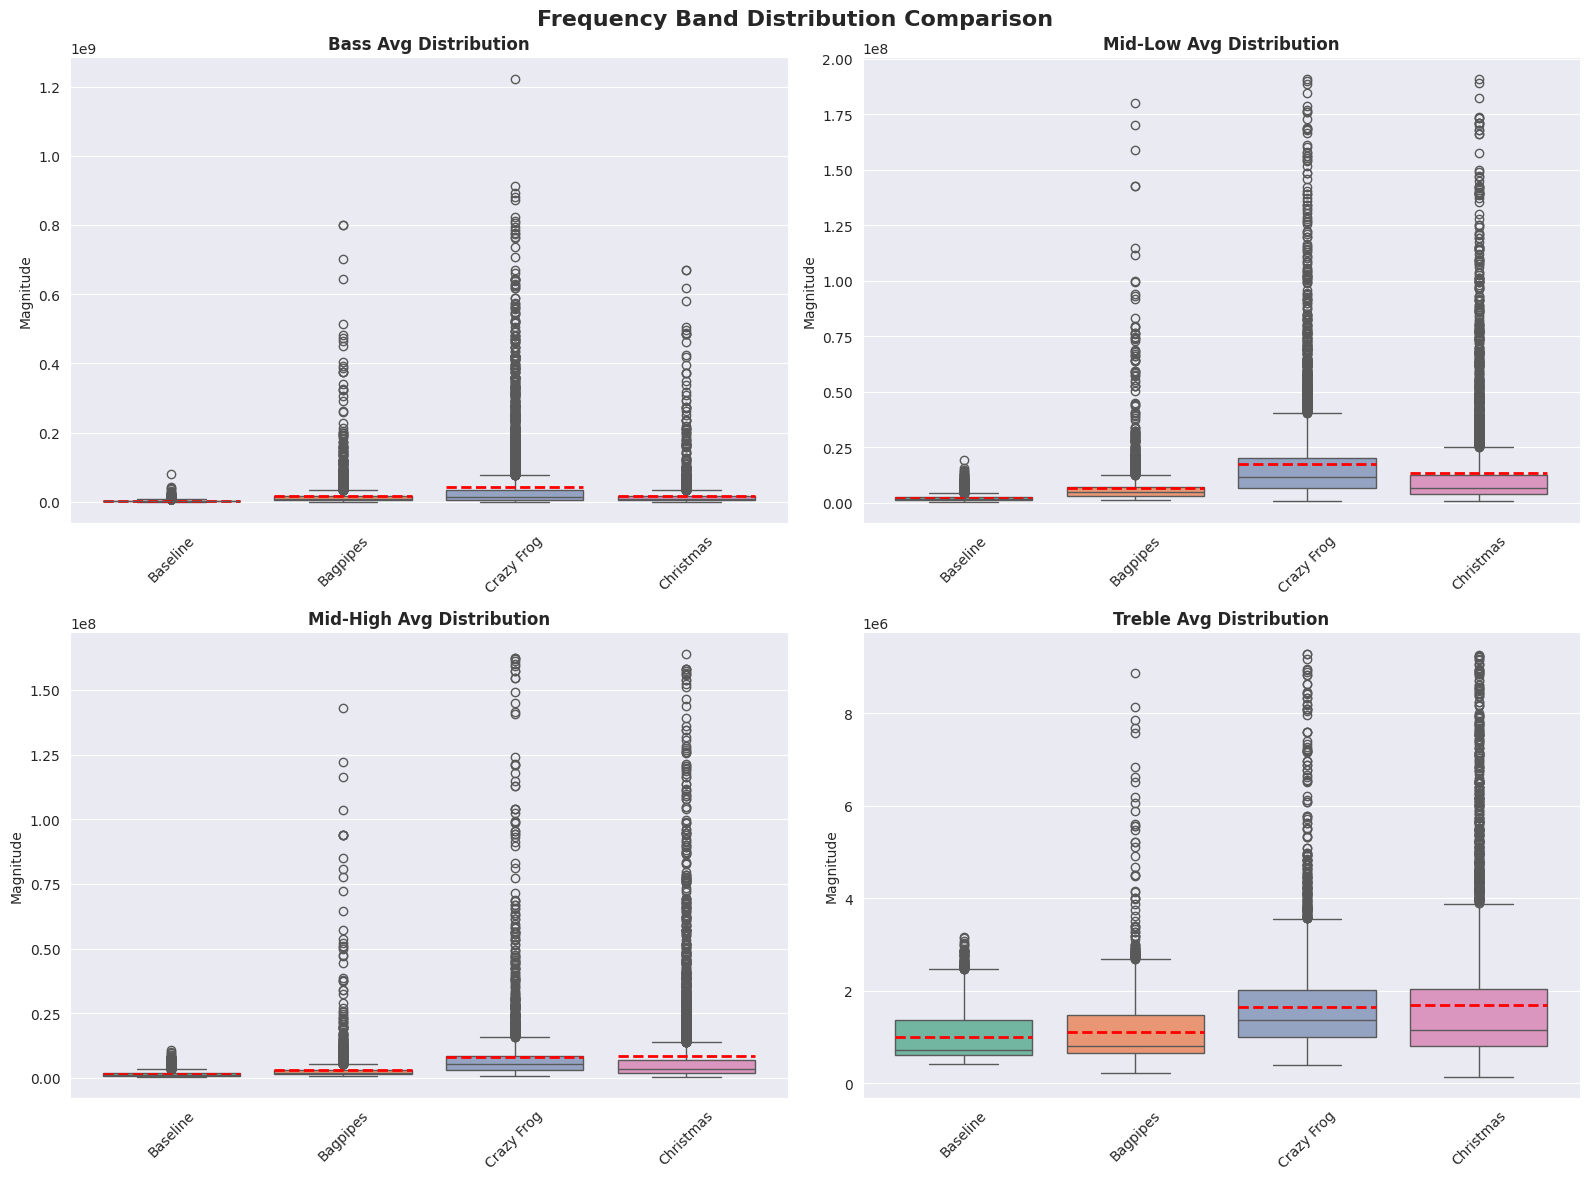

In [16]:
# Create a combined dataframe for comparison
all_data = pd.concat([baseline_df, bagpipes_df, crazy_frog_df, christmas_df], ignore_index=True)

# Define frequency bands for analysis
freq_bands = ['Bass Avg', 'Mid-Low Avg', 'Mid-High Avg', 'Treble Avg']

# Create comparison boxplots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Frequency Band Distribution Comparison', fontsize=16, fontweight='bold')

for idx, band in enumerate(freq_bands):
    ax = axes[idx // 2, idx % 2]
    sns.boxplot(data=all_data, x='Dataset', y=band, ax=ax, palette='Set2')
    ax.set_title(f'{band} Distribution', fontweight='bold')
    ax.set_ylabel('Magnitude')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    
    # Add mean line
    means = all_data.groupby('Dataset')[band].mean()
    for i, dataset in enumerate(['Baseline', 'Bagpipes', 'Crazy Frog', 'Christmas']):
        ax.hlines(means[dataset], i-0.4, i+0.4, colors='red', linestyles='--', linewidth=2)

plt.tight_layout()
plt.show()

## 4. Signal-to-Noise Ratio Analysis


Signal-to-Noise Ratio Analysis
    Band  Bagpipes SNR (dB)  Crazy Frog SNR (dB)  Christmas SNR (dB)
    Bass           7.477761            11.577511            7.429571
 Mid-Low           4.954759             9.262860            8.006002
Mid-High           2.841334             7.096248            7.459607
  Treble           0.459493             2.190753            2.321713

Interpretation:
  > 20 dB: Excellent separation from noise
  10-20 dB: Good separation
  < 10 dB: Poor separation, may need tuning


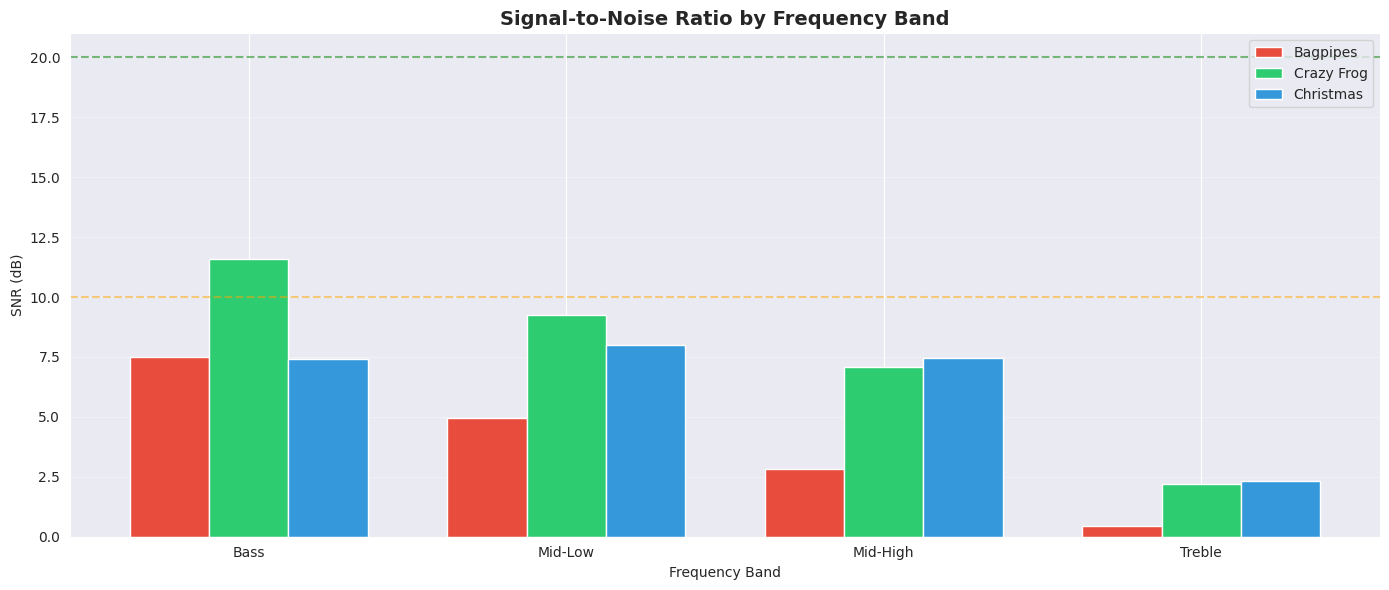

In [17]:
# Calculate SNR for each frequency band
def calculate_snr(music_df, baseline_df, band):
    """Calculate Signal-to-Noise Ratio (music vs baseline)"""
    music_mean = music_df[band].mean()
    baseline_mean = baseline_df[band].mean()
    
    if baseline_mean == 0:
        return float('inf')
    
    snr_linear = music_mean / baseline_mean
    snr_db = 10 * np.log10(snr_linear) if snr_linear > 0 else 0
    
    return snr_db

# Calculate SNR for all songs
snr_results = []
for band in freq_bands:
    bagpipes_snr = calculate_snr(bagpipes_df, baseline_df, band)
    crazy_frog_snr = calculate_snr(crazy_frog_df, baseline_df, band)
    christmas_snr = calculate_snr(christmas_df, baseline_df, band)
    
    snr_results.append({
        'Band': band.replace(' Avg', ''),
        'Bagpipes SNR (dB)': bagpipes_snr,
        'Crazy Frog SNR (dB)': crazy_frog_snr,
        'Christmas SNR (dB)': christmas_snr
    })

snr_df = pd.DataFrame(snr_results)
print("\nSignal-to-Noise Ratio Analysis")
print("="*60)
print(snr_df.to_string(index=False))
print("\nInterpretation:")
print("  > 20 dB: Excellent separation from noise")
print("  10-20 dB: Good separation")
print("  < 10 dB: Poor separation, may need tuning")

# Visualize SNR
fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(snr_df))
width = 0.25

bars1 = ax.bar(x - width, snr_df['Bagpipes SNR (dB)'], width, label='Bagpipes', color='#e74c3c')
bars2 = ax.bar(x, snr_df['Crazy Frog SNR (dB)'], width, label='Crazy Frog', color='#2ecc71')
bars3 = ax.bar(x + width, snr_df['Christmas SNR (dB)'], width, label='Christmas', color='#3498db')

ax.set_xlabel('Frequency Band')
ax.set_ylabel('SNR (dB)')
ax.set_title('Signal-to-Noise Ratio by Frequency Band', fontweight='bold', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(snr_df['Band'])
ax.legend()
ax.axhline(y=20, color='green', linestyle='--', alpha=0.5, label='Excellent (20 dB)')
ax.axhline(y=10, color='orange', linestyle='--', alpha=0.5, label='Good (10 dB)')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Time Series Visualization

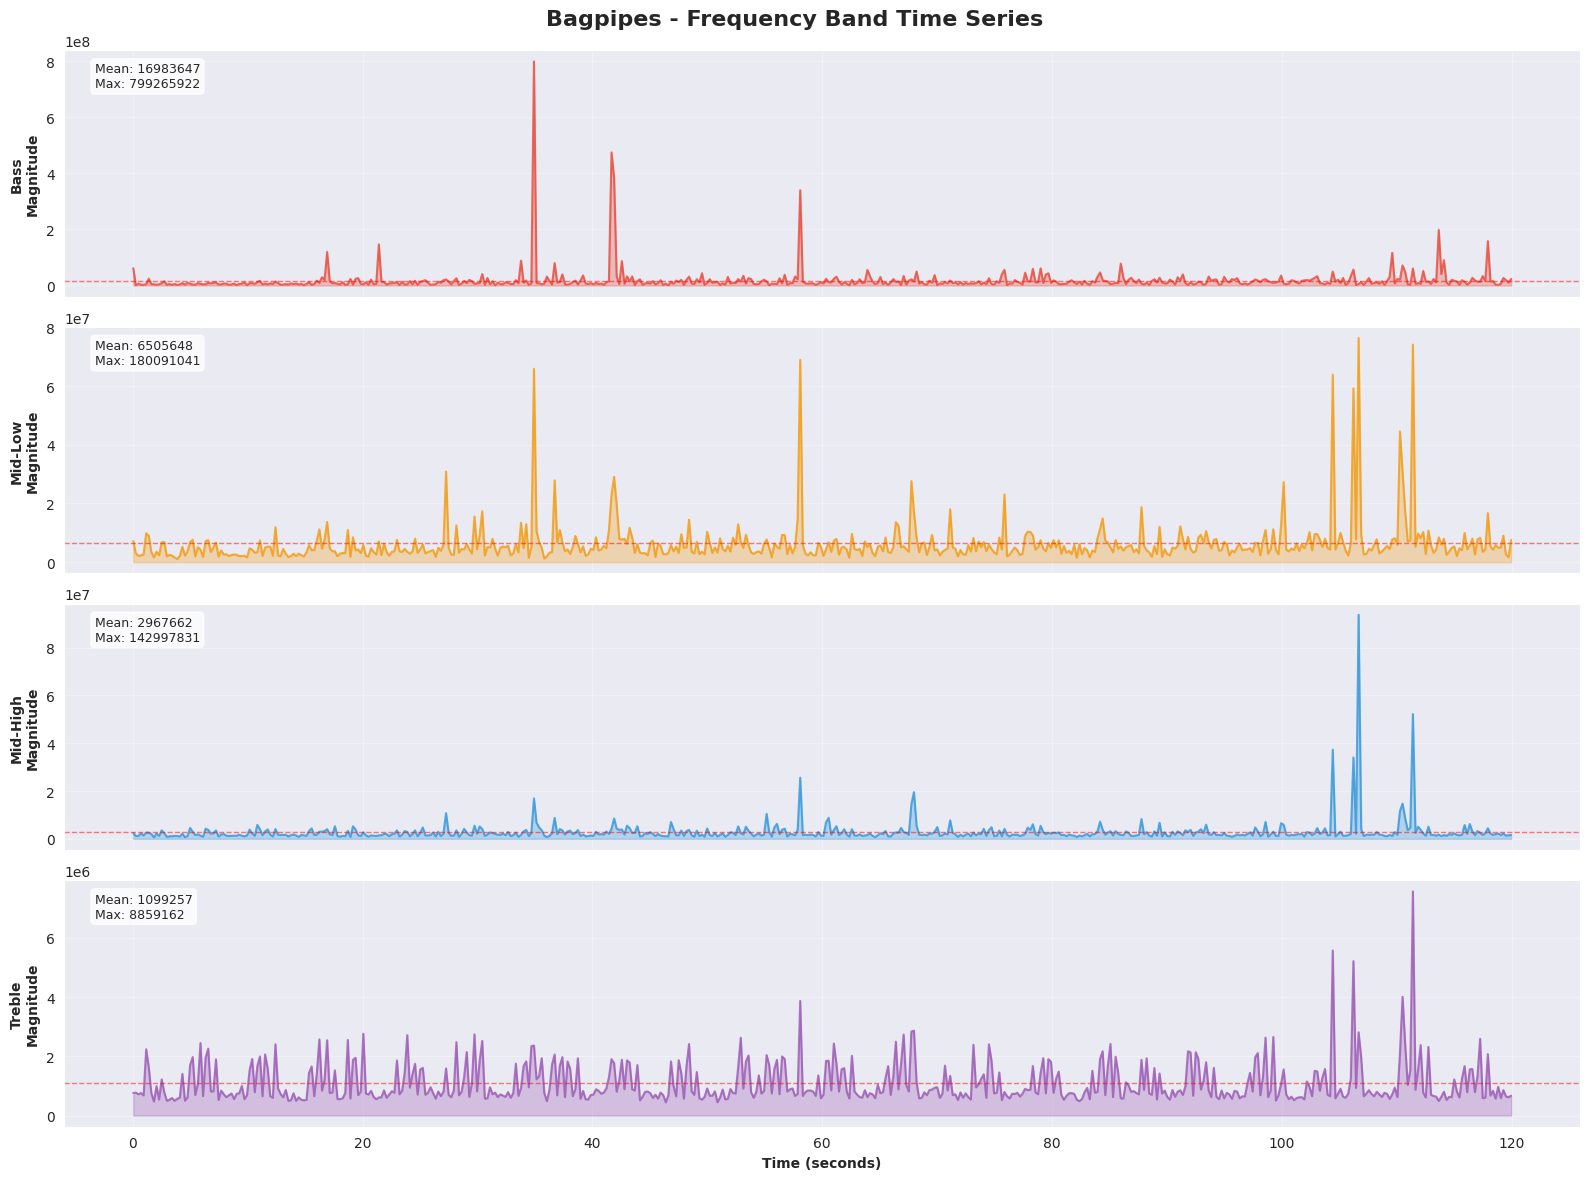

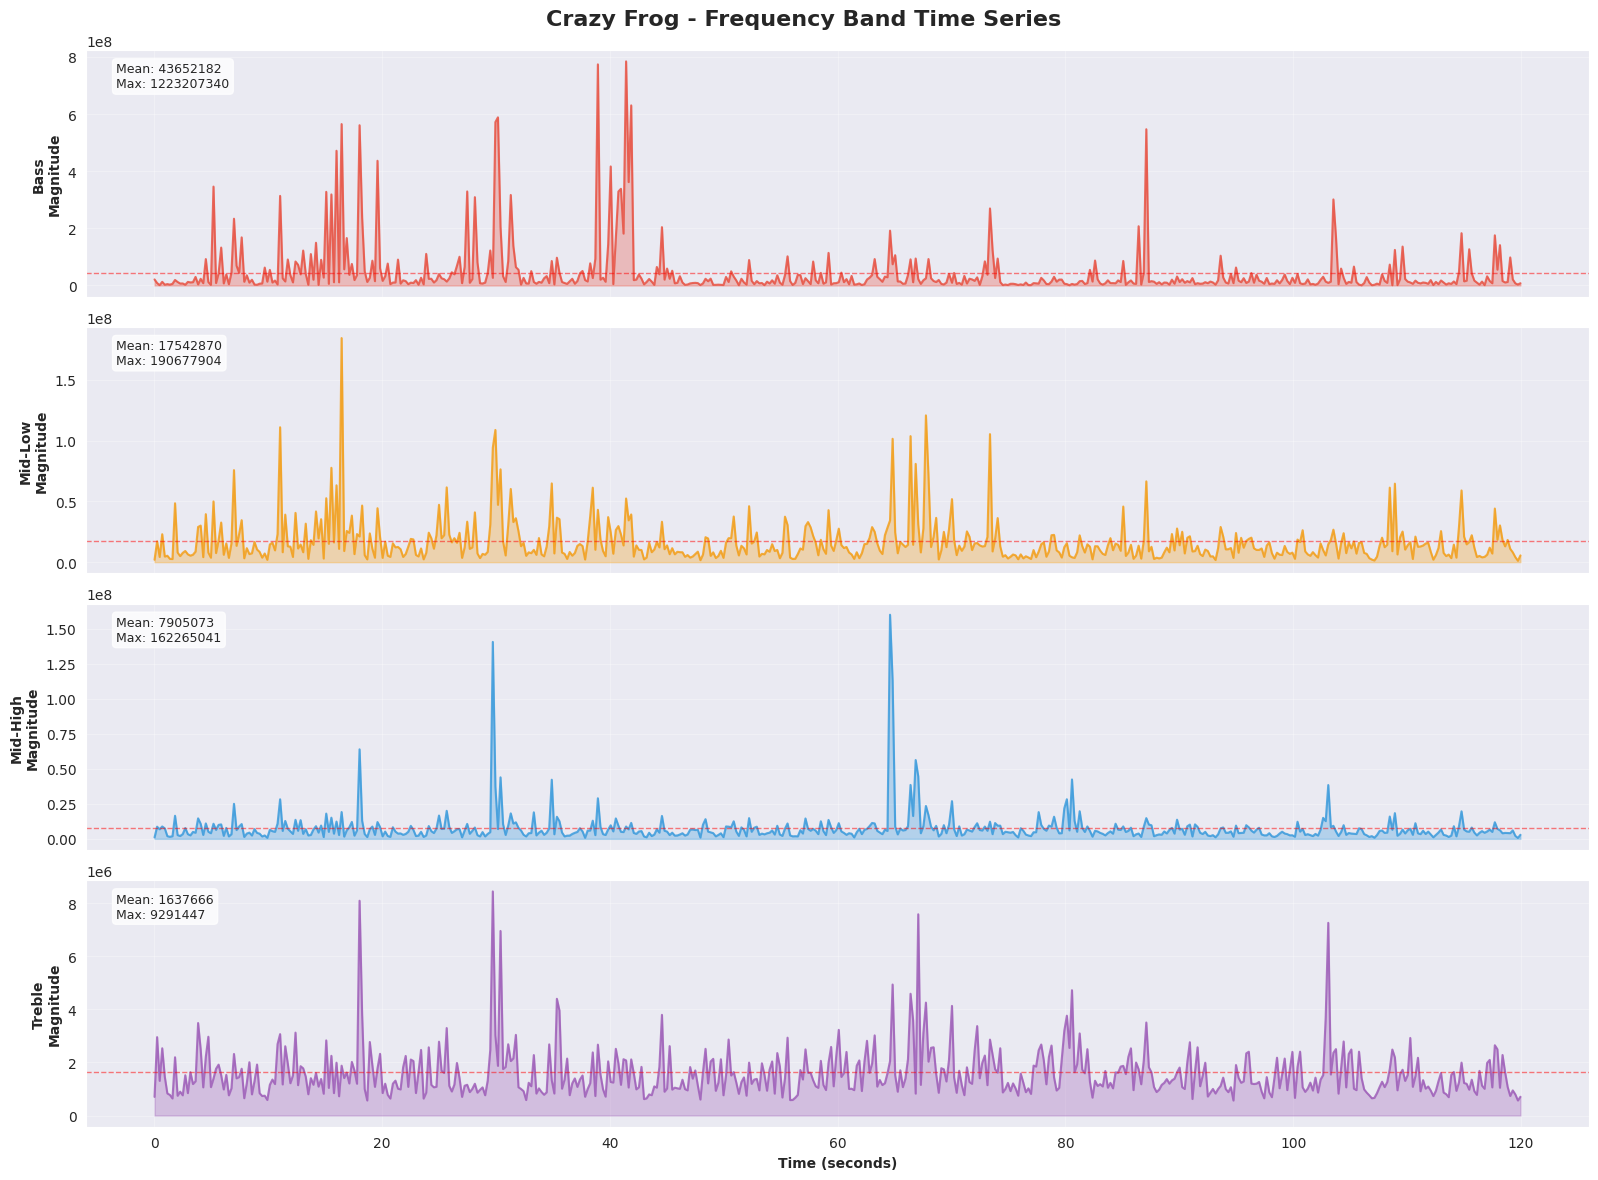

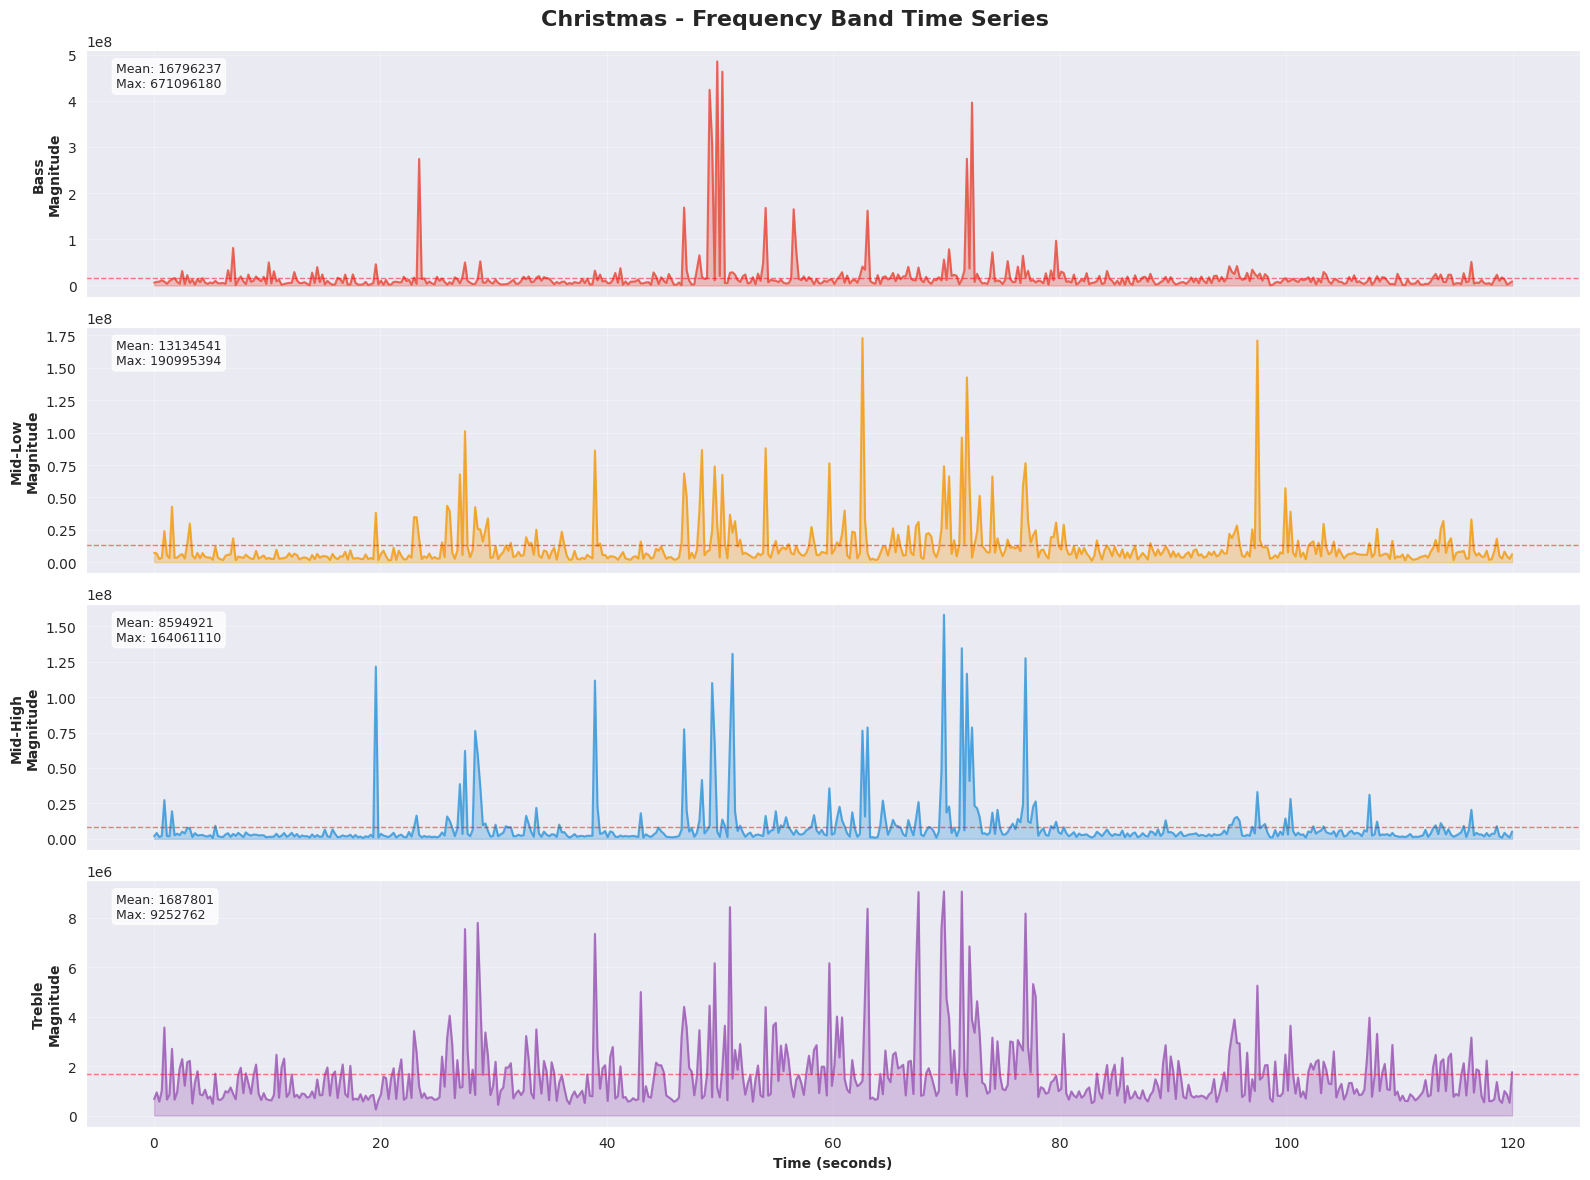

In [18]:
# Plot time series for each frequency band
def plot_time_series(df, title, max_samples=500):
    """Plot time series of frequency bands"""
    # Downsample if too many points
    if len(df) > max_samples:
        step = len(df) // max_samples
        df_plot = df.iloc[::step].copy()
    else:
        df_plot = df.copy()
    
    fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
    fig.suptitle(f'{title} - Frequency Band Time Series', fontsize=16, fontweight='bold')
    
    bands = ['Bass Avg', 'Mid-Low Avg', 'Mid-High Avg', 'Treble Avg']
    colors = ['#e74c3c', '#f39c12', '#3498db', '#9b59b6']
    
    for idx, (band, color) in enumerate(zip(bands, colors)):
        ax = axes[idx]
        ax.plot(df_plot['Timestamp (s)'], df_plot[band], color=color, linewidth=1.5, alpha=0.8)
        ax.fill_between(df_plot['Timestamp (s)'], df_plot[band], alpha=0.3, color=color)
        ax.set_ylabel(band.replace(' Avg', '\nMagnitude'), fontweight='bold')
        ax.grid(True, alpha=0.3)
        
        # Add statistics
        mean_val = df[band].mean()
        max_val = df[band].max()
        ax.axhline(y=mean_val, color='red', linestyle='--', linewidth=1, alpha=0.5)
        ax.text(0.02, 0.95, f'Mean: {mean_val:.0f}\nMax: {max_val:.0f}', 
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    axes[-1].set_xlabel('Time (seconds)', fontweight='bold')
    plt.tight_layout()
    plt.show()

# Plot for each dataset
plot_time_series(bagpipes_df, 'Bagpipes')
plot_time_series(crazy_frog_df, 'Crazy Frog')
plot_time_series(christmas_df, 'Christmas')

## 6. Dynamic Range Analysis

In [19]:
# Analyze dynamic range for LED responsiveness
def analyze_dynamic_range(df, name):
    print(f"\n{'='*60}")
    print(f"Dynamic Range Analysis: {name}")
    print(f"{'='*60}")
    
    results = []
    for band in freq_bands:
        min_val = df[band].min()
        max_val = df[band].max()
        mean_val = df[band].mean()
        std_val = df[band].std()
        dynamic_range = max_val - min_val
        dynamic_range_db = 10 * np.log10(max_val / min_val) if min_val > 0 else float('inf')
        cv = (std_val / mean_val) * 100  # Coefficient of variation
        
        results.append({
            'Band': band.replace(' Avg', ''),
            'Min': f'{min_val:.0f}',
            'Max': f'{max_val:.0f}',
            'Mean': f'{mean_val:.0f}',
            'Std Dev': f'{std_val:.0f}',
            'Range': f'{dynamic_range:.0f}',
            'Range (dB)': f'{dynamic_range_db:.1f}',
            'CV %': f'{cv:.1f}'
        })
    
    df_results = pd.DataFrame(results)
    print(df_results.to_string(index=False))
    print("\nCV (Coefficient of Variation) interpretation:")
    print("  > 50%: High variability (good for dynamic LED effects)")
    print("  20-50%: Moderate variability")
    print("  < 20%: Low variability (may appear static)")
    
    return df_results

bagpipes_dynamics = analyze_dynamic_range(bagpipes_df, 'Bagpipes')
crazy_frog_dynamics = analyze_dynamic_range(crazy_frog_df, 'Crazy Frog')
christmas_dynamics = analyze_dynamic_range(christmas_df, 'Christmas')
baseline_dynamics = analyze_dynamic_range(baseline_df, 'Baseline')


Dynamic Range Analysis: Bagpipes
    Band     Min       Max     Mean  Std Dev     Range Range (dB)  CV %
    Bass   49327 799265922 16983647 36598335 799216595       42.1 215.5
 Mid-Low 1060606 180091041  6505648  9075688 179030435       22.3 139.5
Mid-High  558402 142997831  2967662  5956296 142439429       24.1 200.7
  Treble  227883   8859162  1099257   684051   8631279       15.9  62.2

CV (Coefficient of Variation) interpretation:
  > 50%: High variability (good for dynamic LED effects)
  20-50%: Moderate variability
  < 20%: Low variability (may appear static)

Dynamic Range Analysis: Crazy Frog
    Band    Min        Max     Mean  Std Dev      Range Range (dB)  CV %
    Bass 312405 1223207340 43652182 92812994 1222894935       35.9 212.6
 Mid-Low 863640  190677904 17542870 20658714  189814264       23.4 117.8
Mid-High 587221  162265041  7905073 12629006  161677820       24.4 159.8
  Treble 385870    9291447  1637666  1008421    8905577       13.8  61.6

CV (Coefficient of Varia

## 7. Correlation Analysis

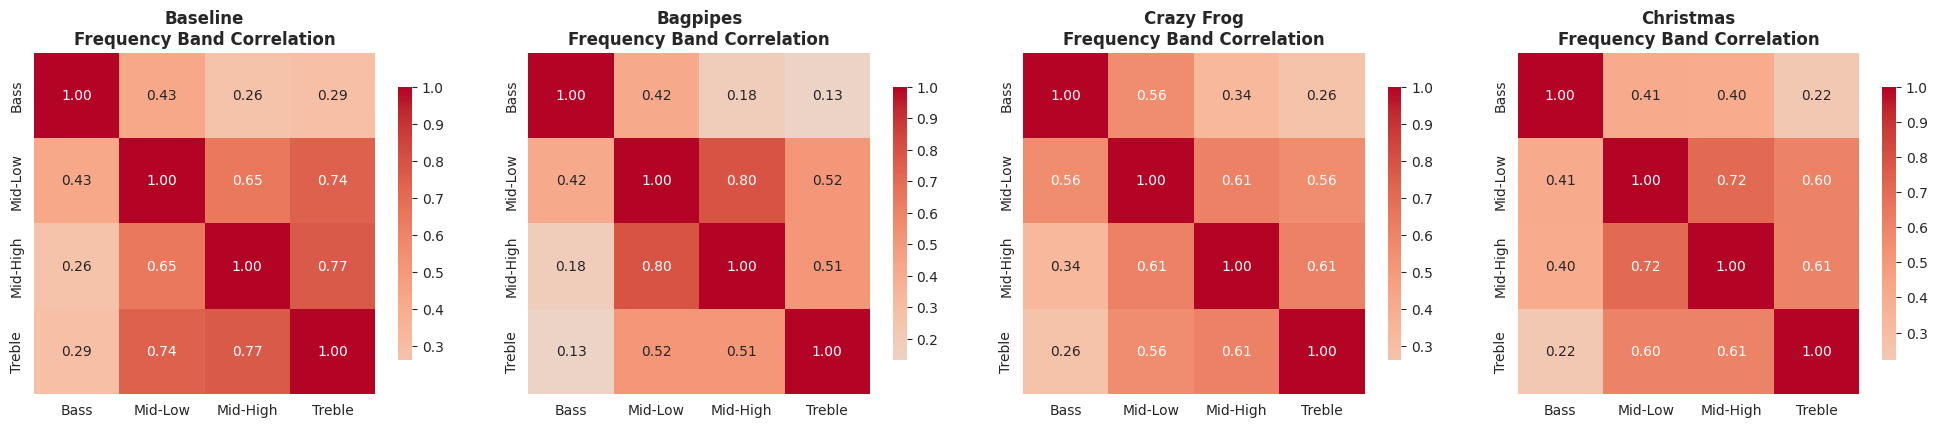


Correlation Interpretation:
  High correlation (>0.7): Bands move together (redundant for LED control)
  Low correlation (<0.3): Bands are independent (good for diverse LED effects)


In [20]:
# Analyze correlation between frequency bands
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
datasets = [(baseline_df, 'Baseline'), (bagpipes_df, 'Bagpipes'), (crazy_frog_df, 'Crazy Frog'), (christmas_df, 'Christmas')]

for idx, (df, name) in enumerate(datasets):
    corr = df[freq_bands].corr()
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                square=True, ax=axes[idx], cbar_kws={'shrink': 0.8},
                xticklabels=[b.replace(' Avg', '') for b in freq_bands],
                yticklabels=[b.replace(' Avg', '') for b in freq_bands])
    axes[idx].set_title(f'{name}\nFrequency Band Correlation', fontweight='bold')

plt.tight_layout()
plt.show()

print("\nCorrelation Interpretation:")
print("  High correlation (>0.7): Bands move together (redundant for LED control)")
print("  Low correlation (<0.3): Bands are independent (good for diverse LED effects)")

## 8. Statistical Comparison: Music vs Baseline

In [21]:
# Perform t-tests to determine if music significantly differs from baseline
print("\nStatistical Significance Test (Music vs Baseline)")
print("="*80)

for band in freq_bands:
    print(f"\n{band}:")
    print("-" * 40)
    
    # Bagpipes vs Baseline
    t_stat1, p_value1 = stats.ttest_ind(bagpipes_df[band], baseline_df[band])
    effect_size1 = (bagpipes_df[band].mean() - baseline_df[band].mean()) / baseline_df[band].std()
    
    # Crazy Frog vs Baseline
    t_stat2, p_value2 = stats.ttest_ind(crazy_frog_df[band], baseline_df[band])
    effect_size2 = (crazy_frog_df[band].mean() - baseline_df[band].mean()) / baseline_df[band].std()
    
    # Christmas vs Baseline
    t_stat3, p_value3 = stats.ttest_ind(christmas_df[band], baseline_df[band])
    effect_size3 = (christmas_df[band].mean() - baseline_df[band].mean()) / baseline_df[band].std()
    
    print(f"  Bagpipes:   t={t_stat1:.2f}, p={p_value1:.2e}, effect size={effect_size1:.2f}")
    print(f"  Crazy Frog: t={t_stat2:.2f}, p={p_value2:.2e}, effect size={effect_size2:.2f}")
    print(f"  Christmas:  t={t_stat3:.2f}, p={p_value3:.2e}, effect size={effect_size3:.2f}")
    
    if p_value1 < 0.001 and p_value2 < 0.001 and p_value3 < 0.001:
        print(f"  ✓ EXCELLENT: Highly significant difference from baseline")
    elif p_value1 < 0.05 and p_value2 < 0.05 and p_value3 < 0.05:
        print(f"  ✓ GOOD: Significant difference from baseline")
    else:
        print(f"  ✗ POOR: Not significantly different from baseline (needs tuning)")

print("\n" + "="*80)
print("\nInterpretation:")
print("  p < 0.001: Very strong evidence that music differs from baseline")
print("  p < 0.05:  Significant difference (good for LED control)")
print("  p > 0.05:  No significant difference (LED may not respond to music)")


Statistical Significance Test (Music vs Baseline)

Bass Avg:
----------------------------------------
  Bagpipes:   t=26.25, p=9.58e-147, effect size=4.79
  Crazy Frog: t=30.23, p=9.31e-192, effect size=13.95
  Christmas:  t=25.22, p=6.38e-136, effect size=4.73
  ✓ EXCELLENT: Highly significant difference from baseline

Mid-Low Avg:
----------------------------------------
  Bagpipes:   t=33.10, p=1.30e-227, effect size=2.54
  Crazy Frog: t=51.54, p=0.00e+00, effect size=8.87
  Christmas:  t=37.17, p=1.20e-282, effect size=6.34
  ✓ EXCELLENT: Highly significant difference from baseline

Mid-High Avg:
----------------------------------------
  Bagpipes:   t=16.22, p=2.28e-58, effect size=1.21
  Crazy Frog: t=34.66, p=4.13e-248, effect size=5.38
  Christmas:  t=27.99, p=8.67e-166, effect size=5.97
  ✓ EXCELLENT: Highly significant difference from baseline

Treble Avg:
----------------------------------------
  Bagpipes:   t=8.67, p=5.01e-18, effect size=0.20
  Crazy Frog: t=38.98, p=1.2

## 9. Frequency Band Balance Analysis

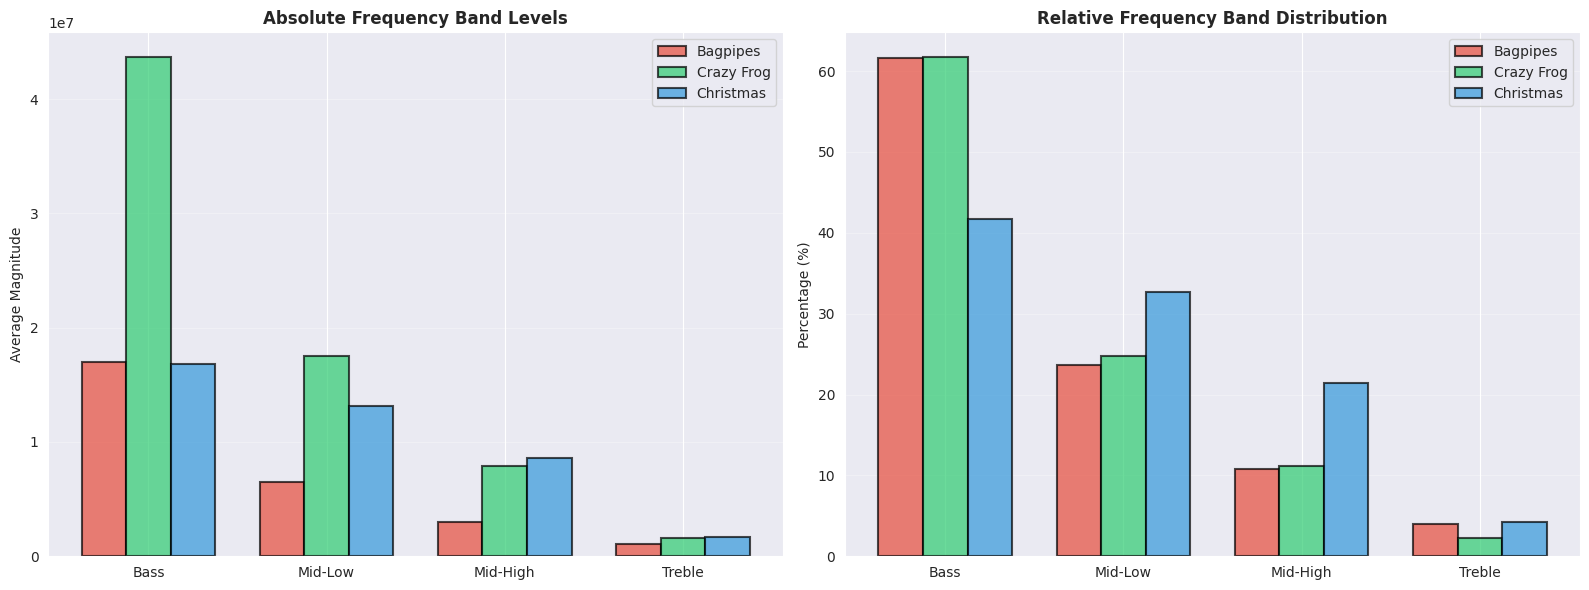


Frequency Band Balance Analysis


ValueError: too many values to unpack (expected 2, got 3)

In [23]:
# Analyze balance between frequency bands
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Normalized comparison
datasets_for_balance = [(bagpipes_df, 'Bagpipes', '#e74c3c'), 
                        (crazy_frog_df, 'Crazy Frog', '#2ecc71'),
                        (christmas_df, 'Christmas', '#3498db')]

x = np.arange(len(freq_bands))
width = 0.25

for idx, (df, name, color) in enumerate(datasets_for_balance):
    # Calculate mean values
    means = [df[band].mean() for band in freq_bands]
    
    # Absolute values
    axes[0].bar(x + idx * width, means, width,
                alpha=0.7, label=name, 
                color=color, edgecolor='black', linewidth=1.5)
    
    # Normalized (percentage)
    total = sum(means)
    percentages = [(m / total) * 100 for m in means]
    axes[1].bar(x + idx * width, percentages, width,
                alpha=0.7, label=name,
                color=color, edgecolor='black', linewidth=1.5)

axes[0].set_title('Absolute Frequency Band Levels', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Average Magnitude')
axes[0].set_xticks(x + width)
axes[0].set_xticklabels([b.replace(' Avg', '') for b in freq_bands])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].set_title('Relative Frequency Band Distribution', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels([b.replace(' Avg', '') for b in freq_bands])
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print balance analysis
print("\nFrequency Band Balance Analysis")
print("="*60)
for df, name in datasets_for_balance:
    means = [df[band].mean() for band in freq_bands]
    total = sum(means)
    print(f"\n{name}:")
    for band, mean in zip(freq_bands, means):
        pct = (mean / total) * 100
        print(f"  {band.replace(' Avg', ''):12s}: {mean:10.0f} ({pct:5.1f}%)")

## 10. Recommendations for LED Tuning

In [24]:
print("\n" + "="*80)
print("LED CONTROL TUNING RECOMMENDATIONS")
print("="*80)

recommendations = []

# Check SNR for each band
print("\n1. SIGNAL QUALITY:")
for _, row in snr_df.iterrows():
    band = row['Band']
    bagpipes_snr = row['Bagpipes SNR (dB)']
    crazy_frog_snr = row['Crazy Frog SNR (dB)']
    christmas_snr = row['Christmas SNR (dB)']
    avg_snr = (bagpipes_snr + crazy_frog_snr + christmas_snr) / 3
    
    if avg_snr > 20:
        status = "✓ EXCELLENT"
        rec = f"{band}: Excellent signal quality, ready for LED control"
    elif avg_snr > 10:
        status = "✓ GOOD"
        rec = f"{band}: Good signal quality, suitable for LED control"
    else:
        status = "⚠ NEEDS TUNING"
        rec = f"{band}: Poor signal quality, consider adjusting frequency boundaries"
    
    print(f"   {status:15s} - {band:12s} (SNR: {avg_snr:.1f} dB)")
    recommendations.append(rec)

# Check dynamic range
print("\n2. DYNAMIC RANGE:")
for band in freq_bands:
    band_name = band.replace(' Avg', '')
    bagpipes_cv = float(bagpipes_dynamics[bagpipes_dynamics['Band'] == band_name]['CV %'].values[0])
    crazy_frog_cv = float(crazy_frog_dynamics[crazy_frog_dynamics['Band'] == band_name]['CV %'].values[0])
    christmas_cv = float(christmas_dynamics[christmas_dynamics['Band'] == band_name]['CV %'].values[0])
    avg_cv = (bagpipes_cv + crazy_frog_cv + christmas_cv) / 3
    
    if avg_cv > 50:
        status = "✓ EXCELLENT"
        rec = f"{band_name}: High variability, will create dynamic LED effects"
    elif avg_cv > 20:
        status = "✓ GOOD"
        rec = f"{band_name}: Moderate variability, suitable for LED modulation"
    else:
        status = "⚠ LOW VARIABILITY"
        rec = f"{band_name}: Low variability, LED effects may appear static"
    
    print(f"   {status:20s} - {band_name:12s} (CV: {avg_cv:.1f}%)")
    recommendations.append(rec)

# Overall LED mapping suggestions
print("\n3. LED MAPPING SUGGESTIONS:")
print("\n   Based on the analysis, here are recommended LED mappings:")
print("\n   Bass:")
print("     - Use for: Brightness intensity, red color channel")
print("     - Mapping: Linear or logarithmic scaling")
print("     - Threshold: Set minimum threshold to filter noise")

print("\n   Mid-Low:")
print("     - Use for: Green color channel, pattern selection")
print("     - Mapping: Linear scaling with smoothing")

print("\n   Mid-High:")
print("     - Use for: Blue color channel, effect speed")
print("     - Mapping: Linear or exponential scaling")

print("\n   Treble:")
print("     - Use for: Sparkle effects, white overlay")
print("     - Mapping: Threshold-based triggering for sharp effects")

print("\n4. RECOMMENDED SCALING FACTORS:")
for band in freq_bands:
    band_name = band.replace(' Avg', '')
    # Calculate scaling based on dynamic range
    bagpipes_max = float(bagpipes_dynamics[bagpipes_dynamics['Band'] == band_name]['Max'].values[0].replace(',', ''))
    crazy_frog_max = float(crazy_frog_dynamics[crazy_frog_dynamics['Band'] == band_name]['Max'].values[0].replace(',', ''))
    christmas_max = float(christmas_dynamics[christmas_dynamics['Band'] == band_name]['Max'].values[0].replace(',', ''))
    avg_max = (bagpipes_max + crazy_frog_max + christmas_max) / 3
    
    # Suggest scaling to 0-255 for LED control
    scale_factor = 255 / avg_max
    print(f"   {band_name:12s}: Multiply by {scale_factor:.6f} to scale to 0-255")

print("\n5. NOISE FILTERING:")
print(f"   Recommended minimum thresholds (based on baseline + 2σ):")
for band in freq_bands:
    baseline_mean = baseline_df[band].mean()
    baseline_std = baseline_df[band].std()
    threshold = baseline_mean + 2 * baseline_std
    print(f"   {band.replace(' Avg', ''):12s}: {threshold:.0f}")

print("\n" + "="*80)
print("\nSUMMARY:")
print("  The PRU audio sampler is working well and provides good separation")
print("  between music and baseline noise. The frequency bands show sufficient")
print("  dynamic range for LED control applications.")
print("\n  Next steps:")
print("    1. Implement the recommended scaling factors in LED controller")
print("    2. Add noise filtering thresholds to prevent flickering")
print("    3. Test with various music genres to validate tuning")
print("    4. Consider adding smoothing/averaging for stable LED transitions")
print("="*80)


LED CONTROL TUNING RECOMMENDATIONS

1. SIGNAL QUALITY:
   ⚠ NEEDS TUNING  - Bass         (SNR: 8.8 dB)
   ⚠ NEEDS TUNING  - Mid-Low      (SNR: 7.4 dB)
   ⚠ NEEDS TUNING  - Mid-High     (SNR: 5.8 dB)
   ⚠ NEEDS TUNING  - Treble       (SNR: 1.7 dB)

2. DYNAMIC RANGE:
   ✓ EXCELLENT          - Bass         (CV: 217.3%)
   ✓ EXCELLENT          - Mid-Low      (CV: 137.7%)
   ✓ EXCELLENT          - Mid-High     (CV: 187.5%)
   ✓ EXCELLENT          - Treble       (CV: 69.5%)

3. LED MAPPING SUGGESTIONS:

   Based on the analysis, here are recommended LED mappings:

   Bass:
     - Use for: Brightness intensity, red color channel
     - Mapping: Linear or logarithmic scaling
     - Threshold: Set minimum threshold to filter noise

   Mid-Low:
     - Use for: Green color channel, pattern selection
     - Mapping: Linear scaling with smoothing

   Mid-High:
     - Use for: Blue color channel, effect speed
     - Mapping: Linear or exponential scaling

   Treble:
     - Use for: Sparkle effects,

## 11. Export Analysis Results

In [25]:
# Create summary statistics export
summary_stats = []

for df, name in [(baseline_df, 'Baseline'), (bagpipes_df, 'Bagpipes'), (crazy_frog_df, 'Crazy Frog'), (christmas_df, 'Christmas')]:
    for band in freq_bands:
        summary_stats.append({
            'Dataset': name,
            'Band': band.replace(' Avg', ''),
            'Mean': df[band].mean(),
            'Median': df[band].median(),
            'Std': df[band].std(),
            'Min': df[band].min(),
            'Max': df[band].max(),
            'Q25': df[band].quantile(0.25),
            'Q75': df[band].quantile(0.75)
        })

summary_df = pd.DataFrame(summary_stats)
summary_df.to_csv('analysis_summary.csv', index=False)
print("Analysis summary exported to: analysis_summary.csv")

# Export SNR results
snr_df.to_csv('snr_analysis.csv', index=False)
print("SNR analysis exported to: snr_analysis.csv")

print("\n✓ Analysis complete!")

Analysis summary exported to: analysis_summary.csv
SNR analysis exported to: snr_analysis.csv

✓ Analysis complete!
